In [1]:
%matplotlib ipympl
import matplotlib
print(matplotlib.get_backend())

ipympl


# MNIST Flow Matching — Demo

This notebook is your entry point. Run cells top-to-bottom.

**What is flow matching?**  
Flow matching learns a vector field $v_\theta(x_t, t)$ that transports a Gaussian noise distribution to the data distribution via straight-path interpolation:
$$x_t = (1-t)\,x_0 + t\,x_1, \quad x_0 \sim \mathcal{N}(0,I),\; x_1 \sim p_{\text{data}}$$
At inference, we integrate the ODE $dx/dt = v_\theta(x_t, t)$ from $t=0$ (noise) to $t=1$ (image).

## 0. Setup

In [2]:
import subprocess, sys

# Install dependencies (safe to re-run)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

# Add src to path
import sys, os
sys.path.insert(0, os.path.abspath("."))

import torch
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.11.0+cu130 | CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti


## 1. Configuration

Edit fields here before training. All other scripts read from this config.

In [3]:
from src.utils import TrainConfig

cfg = TrainConfig(
    epochs=100,          # increase for better quality
    batch_size=512,
    lr=1e-3,
    viz_every=1,         # render a frame every N epochs
    checkpoint_every=10,
    device="cuda",       # set to "cpu" if no GPU
    num_workers=4
)

import json
print(json.dumps(cfg.__dict__, indent=2))

{
  "data_root": "./data",
  "batch_size": 512,
  "num_workers": 4,
  "base_channels": 32,
  "time_embed_dim": 256,
  "epochs": 100,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "lr_warmup_steps": 500,
  "grad_clip": 1.0,
  "ema_decay": 0.9999,
  "checkpoint_dir": "./checkpoints",
  "checkpoint_every": 10,
  "resume_from": null,
  "viz_every": 1,
  "viz_n_samples": 64,
  "viz_n_pca_ref": 1000,
  "runs_dir": "./runs",
  "seed": 42,
  "device": "cuda"
}


## 2. Data Preview

Batch shape: torch.Size([32, 1, 28, 28]) | dtype: torch.float32 | range: [-1.00, 1.00]


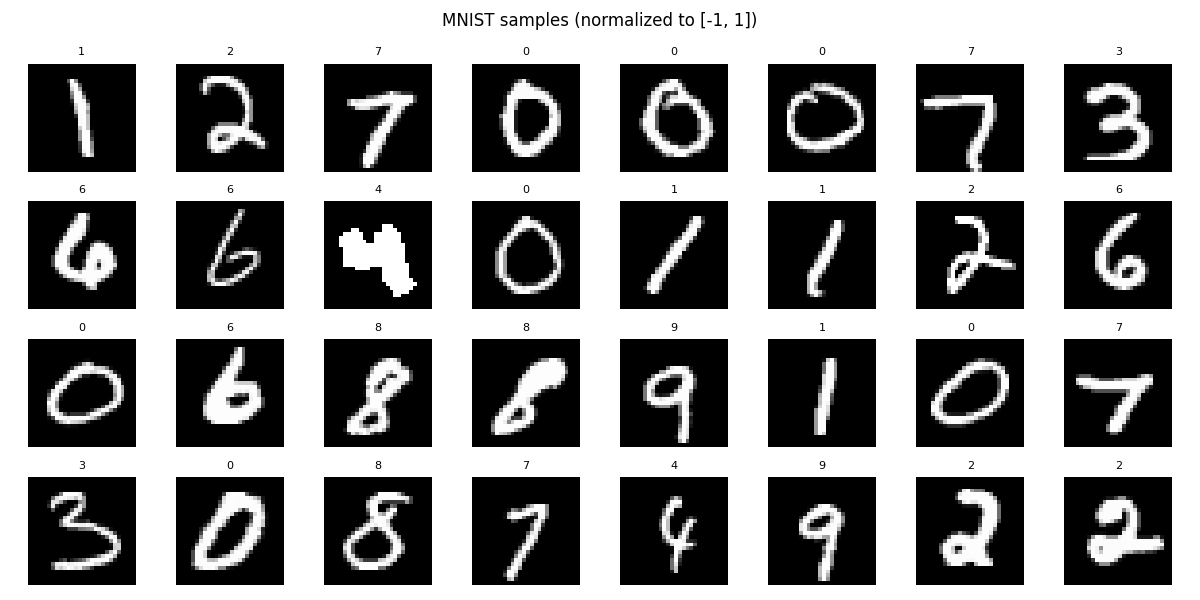

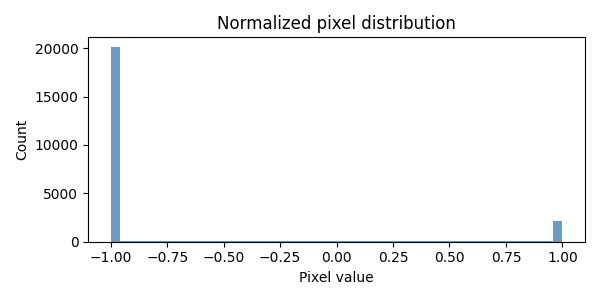

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from src.data import get_mnist_dataloader

loader = get_mnist_dataloader(cfg.data_root, batch_size=32, train=True, num_workers=0)
x, y = next(iter(loader))
print(f"Batch shape: {x.shape} | dtype: {x.dtype} | range: [{x.min():.2f}, {x.max():.2f}]")

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    img = (x[i, 0].numpy() + 1) / 2  # [-1,1] -> [0,1]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(y[i].item()), fontsize=8)
    ax.axis("off")
plt.suptitle("MNIST samples (normalized to [-1, 1])")
plt.tight_layout()
plt.show()

# Pixel distribution
plt.figure(figsize=(6, 3))
plt.hist(x.numpy().ravel(), bins=50, color="steelblue", alpha=0.8)
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Normalized pixel distribution")
plt.tight_layout()
plt.show()

## 3. Model Architecture

In [ ]:
from src.model import UNet

model = UNet(base_ch=cfg.base_channels, time_embed_dim=cfg.time_embed_dim)
n_params = sum(p.numel() for p in model.parameters())
print(f"UNet parameters: {n_params:,} ({n_params/1e6:.2f}M)")

# Verify forward pass shapes
x_dummy = torch.randn(4, 1, 28, 28)
t_dummy = torch.rand(4)
with torch.no_grad():
    out = model(x_dummy, t_dummy)
print(f"Input:  {x_dummy.shape}")
print(f"Output: {out.shape}")
assert out.shape == x_dummy.shape, "Output shape mismatch!"
print("Shape check passed.")

## 4. Training

Runs the full training loop. Progress is printed per epoch.  
Frames are saved to `./runs/frame_XXXX.png` every `viz_every` epochs.

In [ ]:
from train import train
train(cfg)

### Loss Curve

In [ ]:
from IPython.display import Image
Image(f"{cfg.runs_dir}/loss_curve.png", width=600)

## 5. Training Visualization Video

Shows generated samples, PCA scatter, and vector field evolving over training.

In [ ]:
from IPython.display import Video
Video(f"{cfg.runs_dir}/training.mp4", embed=True, width=900)

## 6. Inference & Final Visualization

Loading: checkpoints/ckpt_0099.pt
Loaded EMA model from checkpoints/ckpt_0099.pt (epoch 99)


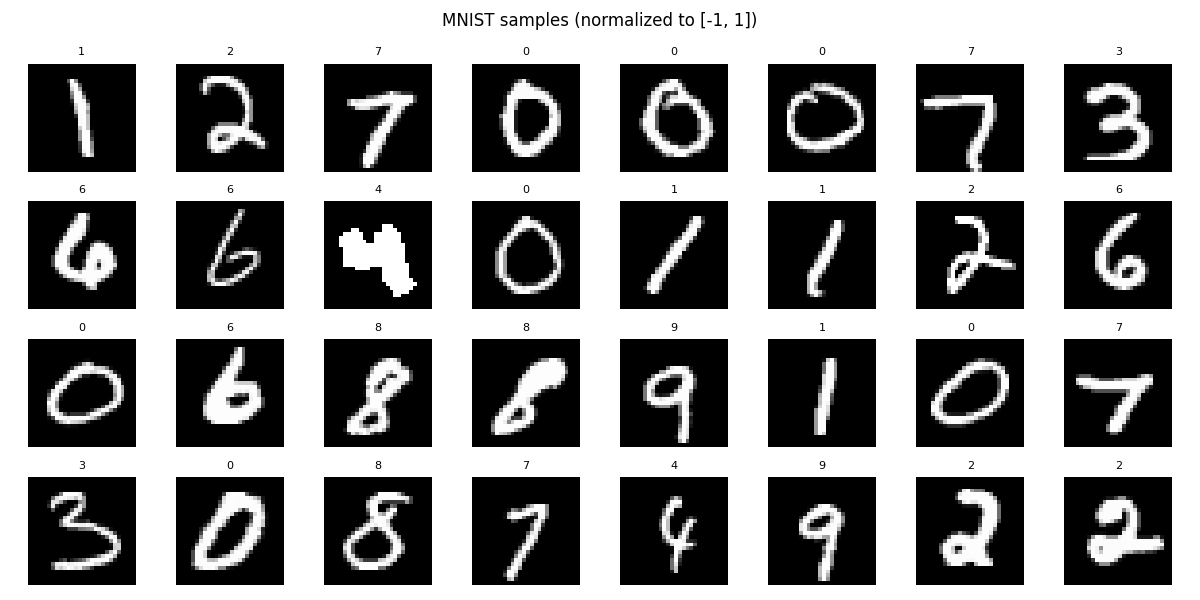

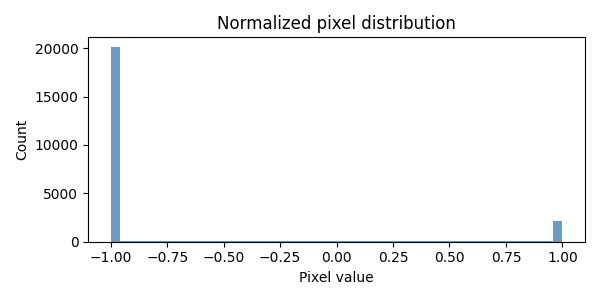

/tmp/ipykernel_141027/3430118279.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
from pathlib import Path
from inference import load_model_from_checkpoint, generate_samples, save_sample_grid

# Find latest checkpoint
ckpt_dir = Path(cfg.checkpoint_dir)
checkpoints = sorted(ckpt_dir.glob("ckpt_*.pt"))
latest_ckpt = str(checkpoints[-1])
print(f"Loading: {latest_ckpt}")

device = torch.device(cfg.device if torch.cuda.is_available() else "cpu")
inf_model = load_model_from_checkpoint(latest_ckpt, device)

# Generate with RK4 (higher quality, fewer steps needed)
samples = generate_samples(inf_model, n_samples=64, solver="rk4", n_steps=100, device=device)

# Display inline
from src.viz import samples_to_grid_np
grid = samples_to_grid_np(samples, nrow=8)

plt.figure(figsize=(10, 10))
plt.imshow(grid.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title(f"64 generated MNIST digits (RK4, 100 steps)")
plt.tight_layout()
plt.show()

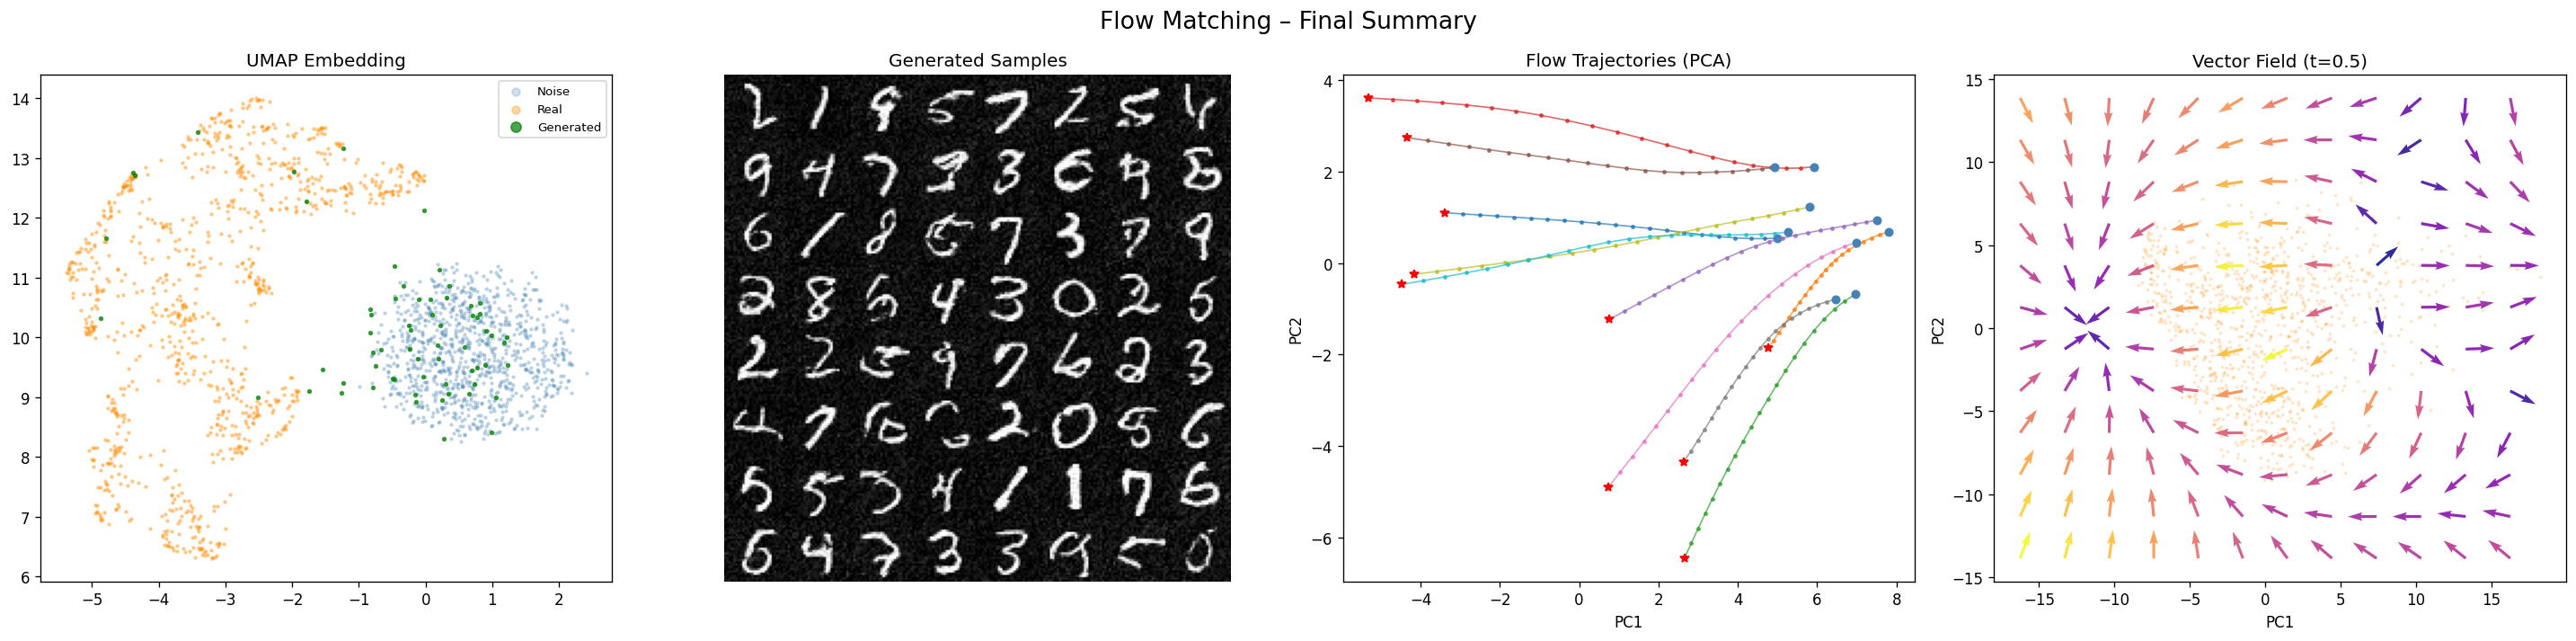

In [6]:
# Final summary figure
from IPython.display import Image
Image(f"{cfg.runs_dir}/final_summary.png", width=1000)

## 7. Interactive Exploration

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from src.ode import euler_solve

# --- Slider: vary n_steps to see quality vs speed tradeoff ---
steps_slider = widgets.IntSlider(value=50, min=5, max=200, step=5, description="n_steps:")
output_steps = widgets.Output()

def on_steps_change(change):
    with output_steps:
        output_steps.clear_output(wait=True)
        n = change["new"]
        torch.manual_seed(42)
        x0 = torch.randn(16, 1, 28, 28, device=device)
        with torch.no_grad():
            s = euler_solve(inf_model, x0, n_steps=n, device=device)
        grid = samples_to_grid_np(s, nrow=4)
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(grid.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(f"Euler, {n} steps")
        plt.tight_layout()
        display(fig)

steps_slider.observe(on_steps_change, names="value")
display(widgets.VBox([steps_slider, output_steps]))
on_steps_change({"new": steps_slider.value})  # trigger initial render

In [9]:
# --- Slider: vary t to watch an image materialize ---
from src.ode import sample_trajectory

# Pre-compute full trajectory
torch.manual_seed(7)
x0_demo = torch.randn(16, 1, 28, 28, device=device)
with torch.no_grad():
    traj = sample_trajectory(inf_model, x0_demo, n_steps=50, return_all=True, device=device)

t_slider = widgets.IntSlider(value=0, min=0, max=len(traj)-1, step=1, description="step:")
output_t = widgets.Output()

def on_t_change(change):
    with output_t:
        output_t.clear_output(wait=True)
        step = change["new"]
        t_frac = step / (len(traj) - 1)
        grid = samples_to_grid_np(traj[step], nrow=4)
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(grid.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
        ax.set_title(f"t = {t_frac:.2f}  (step {step}/{len(traj)-1})")
        plt.tight_layout()
        display(fig)

t_slider.observe(on_t_change, names="value")
display(widgets.VBox([t_slider, output_t]))
on_t_change({"new": 0})